# Comparing sampling when exact velocity is known

Linear flows
The simplest (and, indeed, very powerful) flow is the linear one, $\varphi t(x, y)=\alpha_t x+\sigma_t y$, giving

$$
X_t=\alpha_t X_0+\sigma_t X_1 .
$$


Here, $\alpha, \sigma$ are differentiable functions and must satisfy the constraint $\alpha 0=\sigma 1=1$ and $\alpha 1=\sigma 0=0$. The trajectories are straight lines going from $X_0$ to $X_1$ at a velocity given by

$$
\dot{X}_t=\dot{\alpha}_t X_0+\dot{\sigma}_t X_1 .
$$


In the simplest setting, we can simply choose $\alpha_t=1-t$ and $\sigma_t=t$. This is called rectified flows. The velocity is constant, $\dot{X}_t=X_1-X_0$, so that the flow-matching loss minimizes $\mathbb{E}\left[|s(X_t)-(X_1-X_0)|^2\right]$.
"Gaussian" flows
In practice, the goal of (most) generative models is to sample from $p 0$, which leaves open the choice for $p 1$. The natural choice goes for simplicity, with $p 1=N(0, I d)$. In this case, noting $\varepsilon$ instead of $X_1$, the marginals of (13) are exactly the ones we found for the noising process in diffusions. The conditional velocity $v_t(x)=\mathbb{E}[\dot{X}_t \mid X_t=x]$ is simply

$$
v_t(x)=\dot{\alpha}_t \mathbb{E}[X_0 \mid X_t=x]+\dot{\sigma}_t \mathbb{E}[\varepsilon \mid X_t=x] .
$$


Tweedie's formula, as seen in the preceding note on score matching, gives

$$
v_t(x)=\frac{\dot{\alpha}_t}{\alpha_t} x+\sigma_t^2 \nabla \ln p_t(x)\left[\frac{\dot{\alpha}_t}{\alpha_t}-\frac{\dot{\sigma}_t}{\sigma_t}\right] .
$$


Note that $\dot{\alpha}_t / \alpha_t-\dot{\sigma}_t / \sigma_t$ is equal to $\dot{\lambda}_t / 2$, which is half the time-derivative of the lof-SNR (signel-to-noise) ratio $\lambda t=\ln (\alpha \stackrel{2}{t} / \sigma \stackrel{2}{t})$.
Proof. Tweedie's denoising formula says that since $p_t$ is the distribution of $\alpha_t X_0$ noised by $\sigma_t \varepsilon \sim N\left(0, \sigma_t^2 I d\right)$, then

$$
\mathbb{E}\left[\varepsilon \mid X_t\right]=\frac{\mathbb{E}\left[\sigma_{t \varepsilon} \mid X_t\right]}{\sigma_t}=-\sigma_t \nabla \ln p_t\left(X_t\right) .
$$


Similarly,

$$
\mathbb{E}[X_0 \mid X_t]=\frac{X_t+\sigma_t^2 \nabla \ln p_t(X_t)}{\alpha_t}
$$


Gathering the two yields the formula.

Formula (16) tells us (once again!) that the only thing that matters given the choice of $\alpha_t, \sigma_t$ is the knowledge of the score $\nabla \ln p_t$. How this score was learnt is actually an independent problem: we don't care how the learning was done. When we have the score, we can plug it in (16) and sample.

By carefully looking at the derivations, we can see that there are one-to-one linear connections between
- $\nabla \ln p_t$ (the score)
- $\mathbb{E}[\varepsilon \mid X_t]$ (the denoising model)
- $\mathbb{E}[X_0 \mid X_t]$ (the data prediction model)
- $v_t$ (the velocity model).

Only one of them needs to be learned, and we can convert it into the three others. If one wants to use a pretrained model for sampling, one thus needs to keep_track of how the model was learned: is it a score, a denoiser, a data predictor or a velocity?

We close this part with an important note: given a score model for $\nabla \ln p_t$, regardless of how it is formulated and trained, using it to sample from the flow $\dot{x}_t=v_t(X_t)$ or to sample from the DDIM ODE in diffusion models is exactly the same.

With the rectified-flow choice

$$
\alpha_t=1-t, \quad \sigma_t=t,
$$
So the exact velocity becomes

$$
v_t(x)=\frac{1}{t}\left(x-\mu_t(x)\right)
$$

with

$$
\mu_t(x)=\frac{\int_0^{2 \pi} \gamma(\theta) \sqrt{r(\theta)^2+r^{\prime}(\theta)^2} \exp \left(-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}\right) d \theta}{\int_0^{2 \pi} \sqrt{r(\theta)^2+r^{\prime}(\theta)^2} \exp \left(-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}\right) d \theta}
$$

and

$$
\begin{gathered}
r(\theta)=1+a \sin (n \theta), \quad r^{\prime}(\theta)=a n \cos (n \theta), \\
\gamma(\theta)=(1+a \sin (n \theta))\binom{\cos \theta}{\sin \theta} .
\end{gathered}
$$


So the fully simplified exact velocity field is

$$
v_t(x)=\frac{1}{t}\left[x-\frac{\int_0^{2 \pi} \gamma(\theta) \sqrt{(1+a \sin (n \theta))^2+a^2 n^2 \cos ^2(n \theta)} e^{-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}} d \theta}{\int_0^{2 \pi} \sqrt{(1+a \sin (n \theta))^2+a^2 n^2 \cos ^2(n \theta)} e^{-\frac{\|x-(1-t) \gamma(\theta)\|^2}{2 t^2}} d \theta}\right] .
$$


This is the exact rectified-flow velocity for the star-shaped curve distribution.

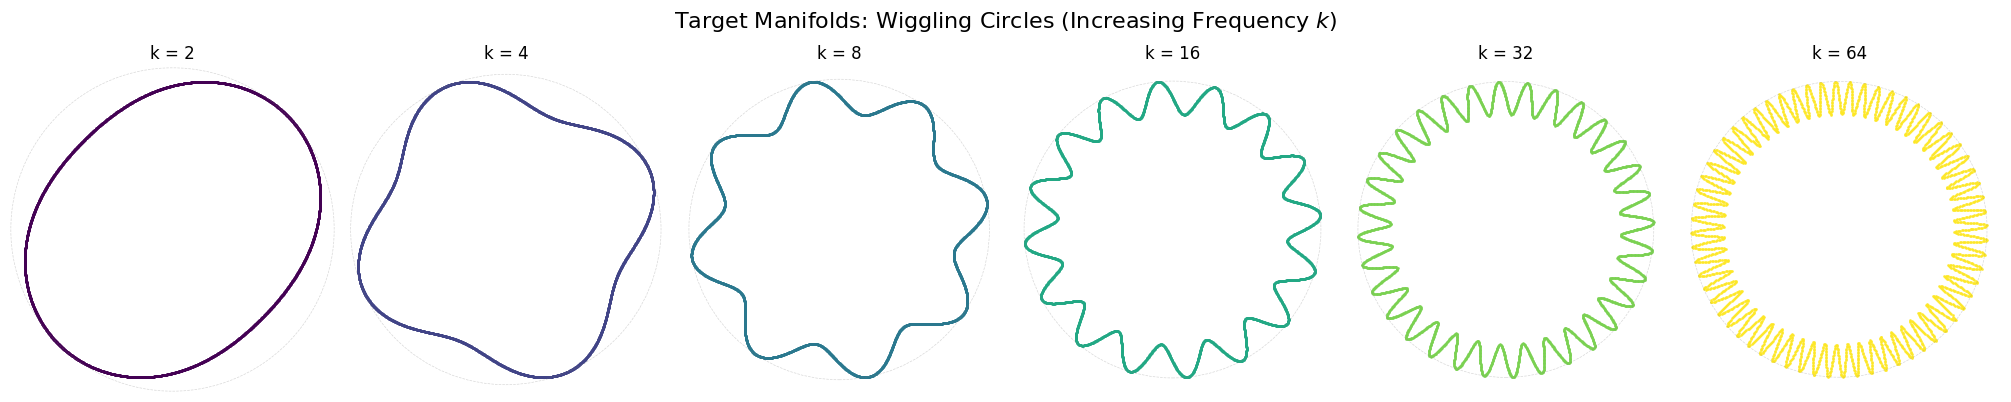

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Data Generation Function ---
def get_wiggling_curve(k, R=1.0, A=0.125, n_samples=3000):
    """Generates arc-length uniform samples for a wiggling circle."""
    n_fine = 1000
    theta_fine = np.linspace(0, 2 * np.pi, n_fine)
    r = R + A * np.sin(k * theta_fine)
    x_fine = r * np.cos(theta_fine)
    y_fine = r * np.sin(theta_fine)
    
    # Cumulative arc length for uniform sampling
    ds = np.sqrt(np.diff(x_fine)**2 + np.diff(y_fine)**2)
    cumulative_length = np.insert(np.cumsum(ds), 0, 0.0)
    
    length_to_theta = interp1d(cumulative_length, theta_fine, kind='linear')
    sampled_lengths = np.linspace(0, cumulative_length[-1], n_samples)
    theta_uniform = length_to_theta(sampled_lengths)
    
    r_u = R + A * np.sin(k * theta_uniform)
    return r_u * np.cos(theta_uniform), r_u * np.sin(theta_uniform)

# --- 2. Plotting Row ---
b_values = [1, 2, 3, 4, 5, 6]
k_values = [2**b for b in b_values]
colors = plt.cm.viridis(np.linspace(0, 1, len(k_values)))

fig, axs = plt.subplots(1, len(k_values), figsize=(20, 4), constrained_layout=True)
fig.suptitle("Target Manifolds: Wiggling Circles (Increasing Frequency $k$)", fontsize=16, y=1.05)

for i, k in enumerate(k_values):
    x, y = get_wiggling_curve(k)
    
    # Plot the curve
    axs[i].scatter(x, y, s=1, color=colors[i], alpha=0.8)
    
    # Formatting
    axs[i].set_title(f"k = {k}")
    axs[i].set_aspect('equal')
    axs[i].axis('off')
    
    # Optional: Add a subtle boundary for scale
    circle = plt.Circle((0, 0), 1.125, color='gray', fill=False, lw=0.5, ls='--', alpha=0.3)
    axs[i].add_patch(circle)

plt.show()

## Exact velocity field & Euler sampler

For rectified flow ($\alpha_t = 1-t$, $\sigma_t = t$) with wiggling-circle target $p_0$:

$$v_t(x) = \frac{x - \mu_t(x)}{t}, \qquad \mu_t(x) = \mathbb{E}[X_0 \mid X_t = x]$$

The posterior mean integrates over the curve with arc-length weighting:

$$\mu_t(x) = \frac{\int_0^{2\pi} \gamma(\theta)\, w(\theta)\, e^{-\|x - (1-t)\gamma(\theta)\|^2 / 2t^2}\, d\theta}{\int_0^{2\pi} w(\theta)\, e^{-\|x - (1-t)\gamma(\theta)\|^2 / 2t^2}\, d\theta}$$

Euler integration runs from $t=1$ (noise $\mathcal{N}(0,I)$) to $t=t_{\min}$ (data).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


def exact_velocity(x, t, n, a=0.125, N_theta=512):
    """
    Exact rectified-flow velocity for wiggling-circle target.

    x       : (N, 2) particle positions at time t
    t       : scalar in (0, 1]
    n       : angular frequency  (k in data-gen code)
    a       : radial amplitude   (A in data-gen code)
    N_theta : quadrature resolution

    Returns (N, 2) velocity vectors.
    """
    theta = np.linspace(0, 2 * np.pi, N_theta, endpoint=False)  # (T,)

    r  =  1.0 + a * np.sin(n * theta)   # (T,)
    dr =  a * n * np.cos(n * theta)      # (T,)
    w  = np.sqrt(r**2 + dr**2)           # arc-length weight (T,)

    gamma = np.stack([r * np.cos(theta),
                      r * np.sin(theta)], axis=1)   # (T, 2)

    # x[:, None, :] - (1-t)*gamma[None, :, :] → (N, T, 2)
    diff    = x[:, None, :] - (1 - t) * gamma[None, :, :]
    sq_dist = np.sum(diff**2, axis=-1)               # (N, T)

    # log-sum-exp for numerical stability
    log_u = np.log(w)[None, :] - sq_dist / (2 * t**2)  # (N, T)
    log_u -= np.max(log_u, axis=1, keepdims=True)
    u = np.exp(log_u)                                    # (N, T)

    Z  = u.sum(axis=1, keepdims=True)                    # (N, 1)
    mu = (u @ gamma) / Z                                 # (N, 2)

    return (x - mu) / t


def euler_sample(n, a=0.125, N_particles=1000, N_steps=200,
                 t_start=1.0, t_min=0.01, N_theta=512, seed=0):
    """
    Euler ODE integration: noise t=t_start  →  data t=t_min.

    Returns (N_particles, 2) approximate samples from the wiggling-circle.
    """
    rng = np.random.default_rng(seed)
    x   = rng.standard_normal((N_particles, 2))

    ts  = np.linspace(t_start, t_min, N_steps + 1)

    for i in range(N_steps):
        t  = ts[i]
        dt = ts[i + 1] - ts[i]          # dt < 0 (integrate backward)
        x  = x + dt * exact_velocity(x, t, n, a=a, N_theta=N_theta)

    return x


print("Functions defined.")


Functions defined.


In [3]:
b_values  = [1, 2, 3, 4, 5, 6]
k_values  = [2**b for b in b_values]
a         = 0.125

N_PARTICLES = 1000
N_STEPS     = 200
N_THETA     = 512

print("Running Euler sampling for each k …")
samples = {}
for k in k_values:
    samples[k] = euler_sample(n=k, a=a,
                              N_particles=N_PARTICLES,
                              N_steps=N_STEPS,
                              N_theta=N_THETA,
                              seed=42)
    print(f"  k={k:3d}  done")
print("All done.")


Running Euler sampling for each k …


  k=  2  done


  k=  4  done


  k=  8  done


  k= 16  done


  k= 32  done


  k= 64  done
All done.


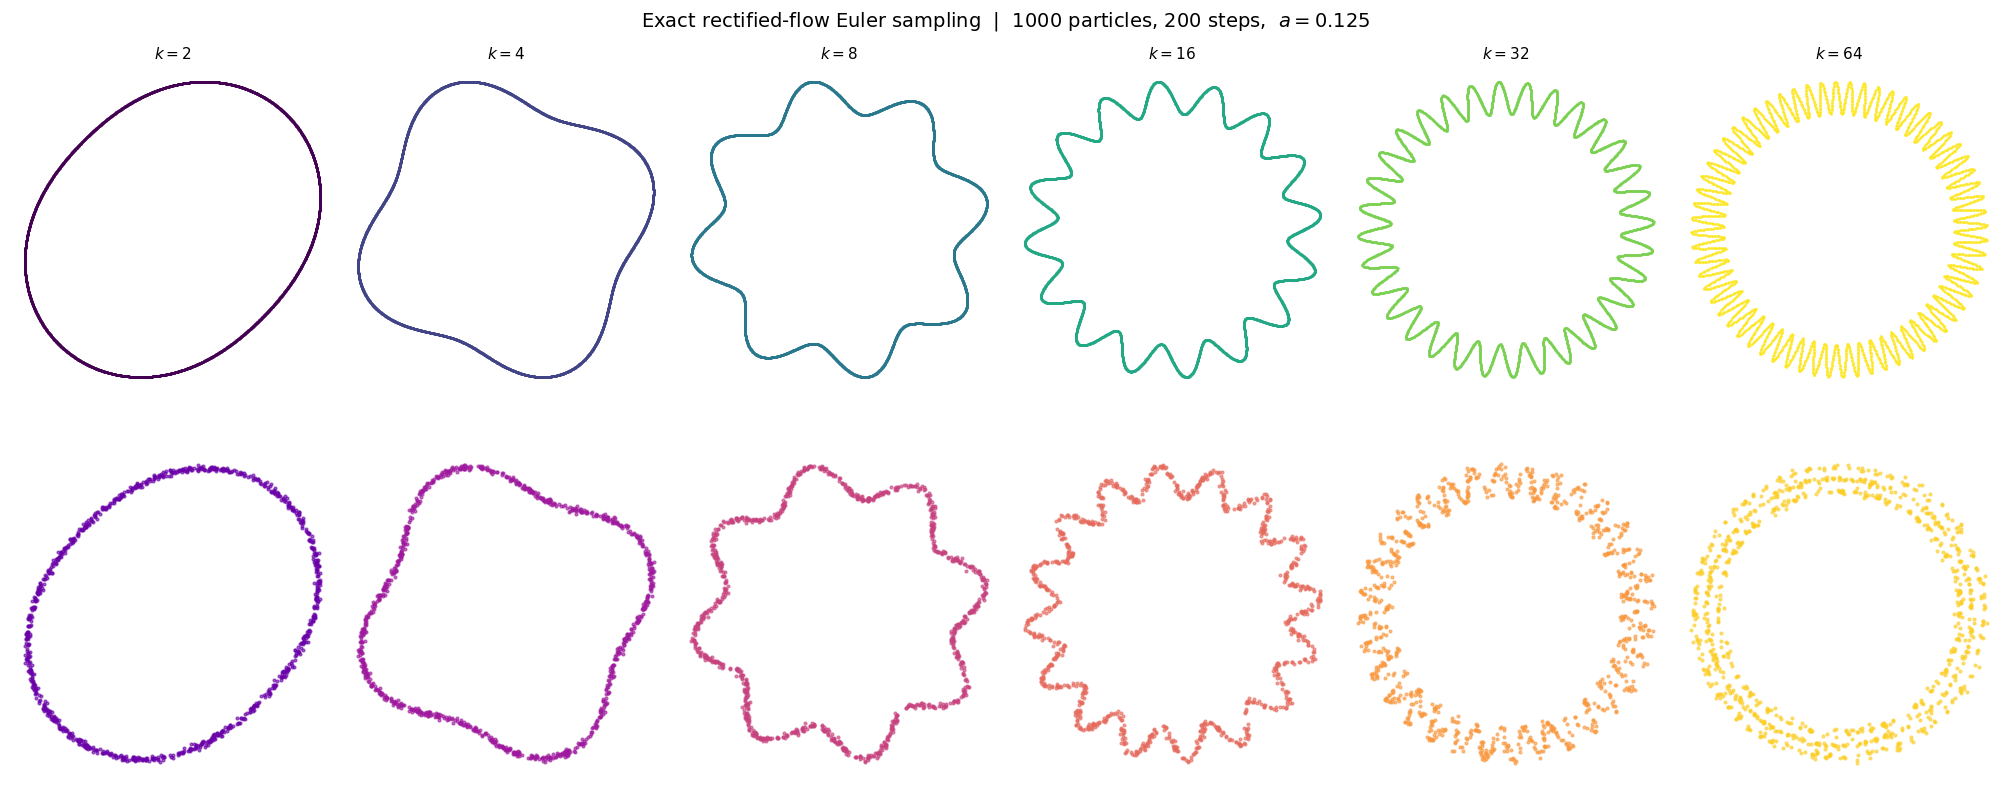

In [4]:
fig, axs = plt.subplots(2, len(k_values), figsize=(20, 8), constrained_layout=True)
fig.suptitle(
    f"Exact rectified-flow Euler sampling  |  "
    f"{N_PARTICLES} particles, {N_STEPS} steps,  $a={a}$",
    fontsize=14,
)

colors_target  = plt.cm.viridis(np.linspace(0, 1, len(k_values)))
colors_samples = plt.cm.plasma(np.linspace(0.2, 0.9, len(k_values)))

for col, k in enumerate(k_values):
    # ── row 0: target curve ──────────────────────────────────────────────
    tx, ty = get_wiggling_curve(k, A=a, n_samples=3000)
    axs[0, col].scatter(tx, ty, s=1, color=colors_target[col], alpha=0.8)
    axs[0, col].set_title(f"$k={k}$", fontsize=11)
    axs[0, col].set_aspect("equal")
    axs[0, col].axis("off")

    # ── row 1: Euler samples ─────────────────────────────────────────────
    sx, sy = samples[k][:, 0], samples[k][:, 1]
    axs[1, col].scatter(sx, sy, s=4, color=colors_samples[col], alpha=0.6)
    axs[1, col].set_aspect("equal")
    axs[1, col].axis("off")

axs[0, 0].set_ylabel("Target", fontsize=11, labelpad=4)
axs[1, 0].set_ylabel("Euler samples", fontsize=11, labelpad=4)
for ax in axs.flat:
    ax.set_ylabel(ax.get_ylabel(), visible=True)

plt.savefig("plots/06-exact-flowmatching.png", dpi=150, bbox_inches="tight")
plt.show()


In [4]:
import ot  # POT: Python Optimal Transport


def w2(x, y):
    """W_2 distance between two (N, 2) point clouds (uniform weights)."""
    n, m = len(x), len(y)
    a = np.ones(n) / n
    b = np.ones(m) / m
    M = ot.dist(x, y, metric='sqeuclidean')   # squared-Euclidean cost
    return np.sqrt(ot.emd2(a, b, M))


def euler_sample_tracked(n, a=0.125, N_particles=500, N_steps=200,
                          t_start=1.0, t_min=0.01, N_theta=512,
                          n_snapshots=50, seed=42):
    """
    Euler integration with particle snapshots at evenly-spaced t values.

    Returns
    -------
    ts_snap  : (n_snapshots,) array of t values (descending, 1 → t_min)
    snaps    : list of (N_particles, 2) arrays, one per snapshot
    """
    rng  = np.random.default_rng(seed)
    x    = rng.standard_normal((N_particles, 2))

    ts        = np.linspace(t_start, t_min, N_steps + 1)
    snap_idxs = set(np.linspace(0, N_steps, n_snapshots, dtype=int))

    ts_snap, snaps = [], []

    for i in range(N_steps):
        if i in snap_idxs:
            ts_snap.append(ts[i])
            snaps.append(x.copy())
        t  = ts[i]
        dt = ts[i + 1] - ts[i]
        x  = x + dt * exact_velocity(x, t, n, a=a, N_theta=N_theta)

    # final snapshot
    ts_snap.append(ts[-1])
    snaps.append(x.copy())

    return np.array(ts_snap), snaps


print("Tracking function defined.")


Tracking function defined.


In [5]:
N_TARGET   = 2000   # target curve samples for W_2 reference
N_PART_W2  = 500    # particles for tracking (W_2 is O(N^2), keep modest)
N_SNAP     = 60

print("Running tracked Euler + computing W_2 …")
w2_results = {}   # k → (ts_snap, w2_vals)

for k in k_values:
    # Reference samples from target curve
    tx, ty = get_wiggling_curve(k, A=a, n_samples=N_TARGET)
    target = np.stack([tx, ty], axis=1)

    ts_snap, snaps = euler_sample_tracked(
        n=k, a=a,
        N_particles=N_PART_W2,
        N_steps=200,
        N_theta=N_THETA,
        n_snapshots=N_SNAP,
        seed=42,
    )

    w2_vals = np.array([w2(snap, target) for snap in snaps])
    w2_results[k] = (ts_snap, w2_vals)
    print(f"  k={k:3d}  W_2(t=1)={w2_vals[0]:.3f}  W_2(t_min)={w2_vals[-1]:.3f}")

print("Done.")


Running tracked Euler + computing W_2 …


  k=  2  W_2(t=1)=0.689  W_2(t_min)=0.060


  k=  4  W_2(t=1)=0.682  W_2(t_min)=0.077


  k=  8  W_2(t=1)=0.655  W_2(t_min)=0.081


  k= 16  W_2(t=1)=0.644  W_2(t_min)=0.095


  k= 32  W_2(t=1)=0.644  W_2(t_min)=0.084


  k= 64  W_2(t=1)=0.645  W_2(t_min)=0.077
Done.


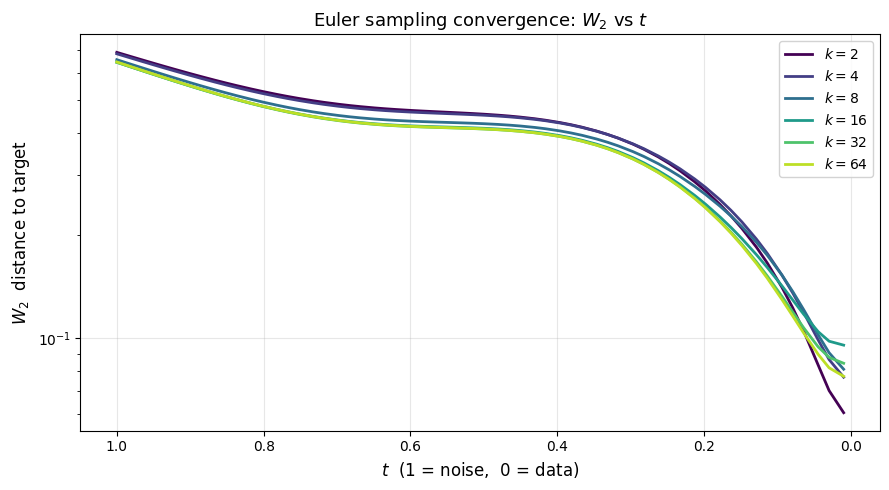

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

palette = plt.cm.viridis(np.linspace(0, 0.9, len(k_values)))

for col, k in enumerate(k_values):
    ts_snap, w2_vals = w2_results[k]
    ax.plot(ts_snap, w2_vals, color=palette[col], lw=2, label=f"$k={k}$")

ax.invert_xaxis()
ax.set_yscale("log")
ax.set_xlabel("$t$  (1 = noise,  0 = data)", fontsize=12)
ax.set_ylabel("$W_2$  distance to target", fontsize=12)
ax.set_title("Euler sampling convergence: $W_2$ vs $t$", fontsize=13)
ax.legend(framealpha=0.85, fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/06-w2-convergence.png", dpi=150, bbox_inches="tight")
plt.show()
